# InSituDiff Perturbation Analysis

This notebook implements the [InSituDiff](https://github.com/Nanostring-Biostats/CosMx-Analysis-Scratch-Space/tree/Main/_code/InSituDiff) perturbation analysis pipeline for CosMx spatial transcriptomics data.

**InSituDiff** compares "cellular neighborhoods" (a cell + its k nearest spatial neighbors) in disease tissues to their most similar matching neighborhood in control tissues, producing a per-cell × per-gene perturbation score (log2 ratio).

**Sections:**
- Parameters
- Libraries
- Data Loading
- Normalization & InSituDiff Inputs
- (Optional) Subsetting
- InSituDiff Initialization
- Gene Perturbation Summary
- Custom Gene Perturbation Scores
- Spatial Maps of Top Perturbed Genes
- Gene Modules (Co-perturbed Gene Clusters)
- Spatial Domain Clustering
- Session Info & Reproducibility

## Parameters

All user-configurable values are defined here. Downstream cells reference these variables — nothing is hardcoded below.

In [22]:
# ── Study & Paths ──
study_name      <- "CJ_TCR_T"
seurat_rds_path <- file.path("/Users/fs2829/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/HIMC_CosMX/Project_CJ/outputs/CJ_TCR_T/seurat_objects/annotated_object_CJ_TCR_T_louvain_final_hieratype_predictors.RDS")
ASSAY_NAME      <- "RNA"

# ── Metadata Column Names ──
sdimx_col       <- "x_slide_mm"
sdimy_col       <- "y_slide_mm"
tissue_col      <- "region_detail"        # metadata column containing tissue/sample IDs
control_pattern <- "Stable"       # regex to identify control tissues in tissue_col

# ── InSituDiff Parameters ──
k                   <- 50          # number of nearest neighbors for neighborhoods
# eps                 <- 0.5         # pseudocount for log2 ratio stability
eps_summarize       <- 0.1         # gene discovery — keep sensitive
eps_spatial         <- 0.2         # gene discovery spatial
eps_modules         <- 0.5         # correlation structure — medium
eps_perturb         <- 1.0         # final plots/outputs — conservative
residtype           <- "log2ratio" # perturbation score type
n_top_genes         <- 20          # number of top perturbed genes to report
nclust              <- 6           # number of spatial clusters
subsetsize          <- 1e5         # subsample size for heavy computations
seed                <- 123         # random seed

# ── Gene Perturbation Thresholds ──
resolution          <- 0.02        # clustering resolution for buildGeneModules
corthresh           <- 0.3         # correlation threshold for gene modules
min_module_cor      <- 0.25        # minimum within-module correlation

# ── Subsetting ──
subset              <- TRUE        # TRUE = subsample cells for faster testing
subset_n            <- 50000       # number of cells to randomly sample when subset = TRUE

# ── Plotting ──
top_genes_to_plot   <- 4           # number of top genes for spatial maps
genes_to_plot       <- NULL        # NULL = auto-select by broadness; or c("GENE1", "GENE2", ...)
n_modules_to_plot   <- NULL        # NULL = plot all modules; or integer for top N largest

# Create output directory
out_dir <- file.path("../outputs", study_name, "InSituDiff")
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
cat("\nOutput directory:", out_dir, "\n")


Output directory: ../outputs/CJ_TCR_T/InSituDiff 


## Libraries

In [2]:
library(Seurat)
library(InSituDiff)
library(Matrix)
library(ggplot2)
library(patchwork)
library(pheatmap)
library(dplyr)
library(data.table)
library(ggrepel)
library(viridis)
library(grDevices)

source("helper_functions.R")

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


Loading required package: viridisLite



## Data Loading

Load the Seurat object and extract the counts matrix, negative probe counts, metadata, and spatial coordinates.

In [3]:
seu <- readRDS(seurat_rds_path)

# Transpose counts: Seurat stores genes×cells, InSituDiff expects cells×genes
counts     <- Matrix::t(seu[[ASSAY_NAME]]$counts)
neg_counts <- Matrix::t(seu[["negprobes"]]$counts)

# Metadata
metadata <- seu@meta.data
metadata$neg_total_counts <- Matrix::rowSums(neg_counts)
metadata$negmean          <- Matrix::rowMeans(neg_counts)

# Spatial coordinates
xy <- as.matrix(metadata[, c(sdimx_col, sdimy_col)])

# Alignment checks
stopifnot(all(rownames(counts) == rownames(metadata)))
stopifnot(all(rownames(counts) == rownames(xy)))

cat("Cells:", nrow(counts), " Genes:", ncol(counts), "\n")
cat("Negative probes:", ncol(neg_counts), "\n")

Cells: 294534  Genes: 958 
Negative probes: 10 


## Normalization & InSituDiff Inputs

Normalize counts using library-size scaling (mean-based), then prepare the tissue and control vectors for InSituDiff.

In [4]:
# Normalize counts using efficient sparse matrix scaling
scale_row <- mean(metadata$nCount_RNA) / metadata$nCount_RNA
norm <- counts
norm@x <- norm@x * scale_row[norm@i + 1L]

# Tissue vector and control indicator
tissue    <- metadata[[tissue_col]]
iscontrol <- grepl(control_pattern, tissue, ignore.case = TRUE)

cat("Control/Disease cell counts:\n")
print(table(condition = ifelse(iscontrol, "control", "disease"), tissue = tissue))

Control/Disease cell counts:
         tissue
condition BRHS76350 (Stable disease) BRHS77548 (Complete response)
  control                      50025                             0
  disease                          0                         53717
         tissue
condition BRHS80975 (No response) BRHS81230 (No response)
  control                       0                       0
  disease                   77324                  113468


## (Optional) Subsetting

Randomly subsample cells for faster testing. When `subset = TRUE`, all downstream objects (`counts`, `norm`, `metadata`, `xy`, `tissue`, `iscontrol`) are subset to `subset_n` cells. Set `subset = FALSE` for production runs.

In [5]:
if (subset) {
    set.seed(seed)
    n_total <- nrow(counts)
    n_keep  <- min(subset_n, n_total)
    keep_idx <- sort(sample.int(n_total, n_keep))

    counts   <- counts[keep_idx, ]
    norm     <- norm[keep_idx, ]
    metadata <- metadata[keep_idx, ]
    xy       <- xy[keep_idx, ]
    tissue   <- tissue[keep_idx]
    iscontrol <- iscontrol[keep_idx]

    cat("Subsetted to", n_keep, "of", n_total, "cells\n")
} else {
    cat("No subsetting — using all", nrow(counts), "cells\n")
}

Subsetted to 50000 of 294534 cells


## InSituDiff Initialization

`initializeISD()` builds two key data structures:

1. **Neighbors matrix**: For each cell, its k nearest spatial neighbors within the same tissue. This defines "cellular neighborhoods."
2. **Control matches**: For each disease cell's neighborhood, the most similar neighborhood in control tissues (matched by expression profile). Control cells will have `NA` match values.

**`eps` trade-off**: The epsilon pseudocount stabilizes the log2 ratio when expression is near zero. Higher values = more stable but less sensitive to small perturbations; lower values = more sensitive but noisier.

In [6]:
obj <- tryCatch({
    InSituDiff::initializeISD(
        mat       = norm,
        xy        = xy,
        tissue    = tissue,
        iscontrol = iscontrol,
        k         = k
    )
}, error = function(e) {
    stop("initializeISD() failed: ", e$message)
})

str(obj)

Only 1 control tissue was input. Arbitrarily splitting it into 5 regions. Perturbation values on the control sample will be uncertain; perturbation values of disease samples are unaffected.



List of 4
 $ neighbors     :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. ..@ i       : int [1:2500000] 947 948 3705 3707 3708 3709 3710 3711 5804 5805 ...
  .. ..@ p       : int [1:50001] 0 60 103 152 192 249 307 357 410 462 ...
  .. ..@ Dim     : int [1:2] 50000 50000
  .. ..@ Dimnames:List of 2
  .. .. ..$ : chr [1:50000] "1_c_1_100_2062" "1_c_1_100_3045" "1_c_1_100_3061" "1_c_1_100_3269" ...
  .. .. ..$ : chr [1:50000] "1_c_1_100_2062" "1_c_1_100_3045" "1_c_1_100_3061" "1_c_1_100_3269" ...
  .. ..@ x       : num [1:2500000] 0.05828 0.07289 0.04051 0.00894 0.06489 ...
  .. ..@ factors : list()
 $ controlmatches: chr [1:50000, 1] "2_c_2_120_124" "2_c_2_120_124" "2_c_2_120_124" "2_c_2_120_124" ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:50000] "1_c_1_100_2062" "1_c_1_100_3045" "1_c_1_100_3061" "1_c_1_100_3269" ...
  .. ..$ : NULL
 $ tissue        : chr [1:50000] "BRHS77548 (Complete response)_dis" "BRHS77548 (Complete response)_dis" "BRHS77548 (Complete r

## Gene Perturbation Summary

For each gene, two scores summarize its perturbation:
- **Broadness**: How widely perturbed across disease cells (mean disease perturbation / mean control perturbation)
- **Intensity**: How strongly perturbed in the most affected cells (mean+2SD disease / mean+2SD control)

*Note: the actual implementation computes ratios of squared perturbation scores with pseudocount offsets — see `?summarizeGenePerturbation` for details.*

`identifyMostPerturbedGenes()` selects the top HPGs ranked by intensity.

In [9]:
genescores <- tryCatch({
    InSituDiff::summarizeGenePerturbation(
        x           = norm,
        obj         = obj,
        residtype   = residtype,
        plotresults = FALSE,
        eps         = eps_summarize,
        subsetsize  = subsetsize
    )
}, error = function(e) {
    stop("summarizeGenePerturbation() failed: ", e$message)
})

cat("Gene scores dimensions:", dim(genescores), "\n")
cat("Column names:", colnames(genescores), "\n")
head(genescores[order(-genescores[, "broadness"]), ], n_top_genes)

Gene scores dimensions: 958 2 
Column names: broadness intensity 


,broadness,intensity
KRT5,18.282146,15.029238
HSPB1,16.856997,16.998211
COL1A1,14.396315,17.979697
S100A8,11.367758,12.396988
TPT1,11.323346,8.938961
KRT19,10.044180,10.270401
IGHG1,10.022401,7.381953
SFN,9.815058,8.720075
B2M,9.357572,10.766997
IGKC,7.399990,8.034334


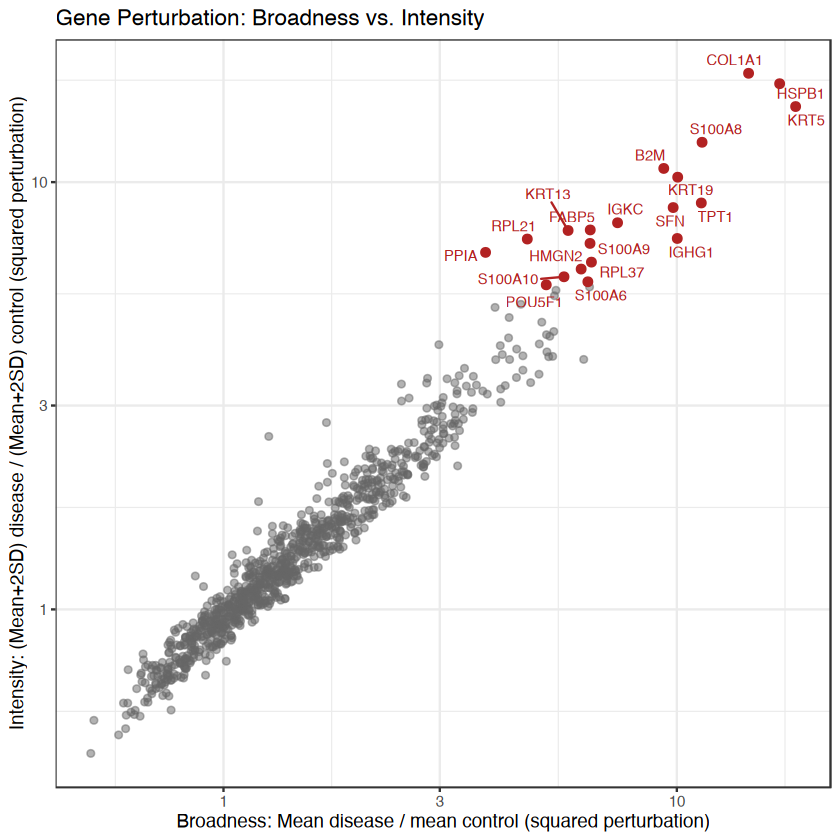

In [11]:
# Broadness vs. Intensity scatter plot (log scale, matching plotresults=TRUE behavior)
gs_df <- as.data.frame(genescores)
gs_df$gene <- rownames(gs_df)

# Label top genes by intensity
top_label <- head(gs_df[order(-gs_df$intensity), ], n_top_genes)

p_scatter <- ggplot(gs_df, aes(x = broadness, y = intensity)) +
    geom_point(alpha = 0.5, size = 1.5, color = "grey40") +
    geom_point(data = top_label, color = "firebrick", size = 2) +
    geom_text_repel(data = top_label, aes(label = gene),
                    size = 3, max.overlaps = 20, color = "firebrick") +
    scale_x_log10() + scale_y_log10() +
    theme_bw() +
    labs(title = "Gene Perturbation: Broadness vs. Intensity",
         x = "Broadness: Mean disease / mean control (squared perturbation)",
         y = "Intensity: (Mean+2SD) disease / (Mean+2SD) control (squared perturbation)")

p_scatter

Highly perturbed genes (n = 20 ):
 [1] "COL1A1"  "HSPB1"   "KRT5"    "S100A8"  "B2M"     "KRT19"   "TPT1"   
 [8] "SFN"     "IGKC"    "FABP5"   "KRT13"   "IGHG1"   "RPL21"   "S100A9" 
[15] "PPIA"    "RPL37"   "HMGN2"   "S100A10" "S100A6"  "POU5F1" 

Saved gene_perturbation_scores.csv to ../outputs/CJ_TCR_T/InSituDiff 


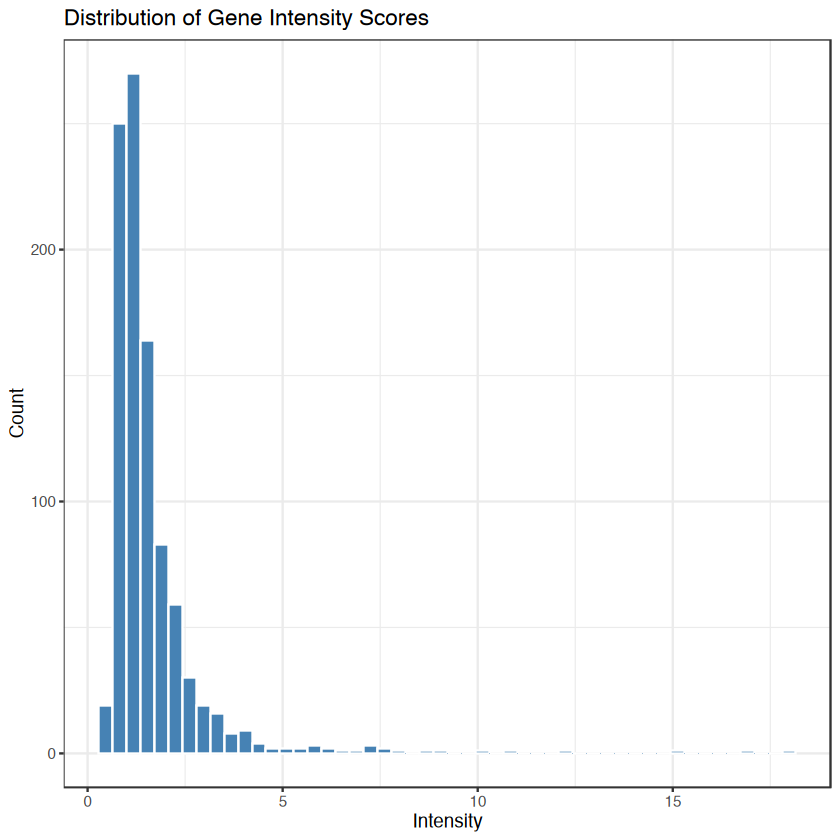

In [ ]:
# Identify highly perturbed genes using identifyMostPerturbedGenes()
hpgs <- InSituDiff::identifyMostPerturbedGenes(genescores, n = n_top_genes)


# Or define via threshold
# hpgs <- rownames(genescores)[genescores[, "broadness"] > thresh]
# print(paste0("Highly perturbed genes: ", paste0(hpgs, collapse = ", ")))

cat("Highly perturbed genes (n =", length(hpgs), "):\n")
print(hpgs)

# Histogram of intensity scores
p_hist <- ggplot(gs_df, aes(x = intensity)) +
    geom_histogram(bins = 50, fill = "steelblue", color = "white") +
    theme_bw() +
    labs(title = "Distribution of Gene Intensity Scores",
         x = "Intensity", y = "Count")

p_hist

# Save gene scores
write.csv(as.data.frame(genescores), file.path(out_dir, "gene_perturbation_scores.csv"))
cat("\nSaved gene_perturbation_scores.csv to", out_dir, "\n")

## Custom Gene Perturbation Scores

At any point you can compute a matrix of perturbation scores for any cells and genes of interest using `getPerturbations()`. Pass `cells = NULL, genes = NULL` for all cells/genes — but beware of memory on large datasets.

**`eps` matters here**: it is added to expression values before taking log2 ratios. Higher values stabilize low-expressing genes but suppress their apparent perturbations. Lower values give better sensitivity for low expressers but produce noisier results. We use `eps_perturb` (conservative) for these outputs.

In [16]:
# Define genes of interest (default: use the highly perturbed genes)
genes_of_interest <- hpgs

# Score perturbations for genes of interest across all cells
selectedperturbations <- InSituDiff::getPerturbations(
    x         = norm,
    obj       = obj,
    cells     = NULL,
    genes     = genes_of_interest,
    residtype = residtype,
    eps       = eps_perturb
)

print(paste("Eps used:", eps_perturb))

# Result is a dense matrix: cells x genes
cat("Perturbation matrix:", nrow(selectedperturbations), "cells x",
    ncol(selectedperturbations), "genes\n")
selectedperturbations[1:5, 1:min(5, ncol(selectedperturbations))]

[1] "Eps used: 1"
Perturbation matrix: 50000 cells x 20 genes


,COL1A1,HSPB1,KRT5,S100A8,B2M
1_c_1_100_2062,-0.8038497,0.8676514,1.420342,0.2809586,0.46117552
1_c_1_100_3045,-0.4994845,0.6180211,1.693276,0.5708433,-0.08152215
1_c_1_100_3061,-0.6356326,0.5565875,1.399948,0.4408193,0.57408782
1_c_1_100_3269,-0.5539960,0.6053883,1.292693,0.5065055,-0.02722874
1_c_1_100_547,-0.1686563,0.8869785,1.484043,1.1710448,0.72829821


## Spatial Maps of Top Perturbed Genes

Visualize the spatial distribution of perturbation scores for the top highly perturbed genes. Each cell is colored by its perturbation score using a diverging blue-white-red palette centered at 0. Control cells (with no disease match) are shown in grey.

Plotting perturbation maps for: COL1A1, HSPB1, KRT5, S100A8 


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


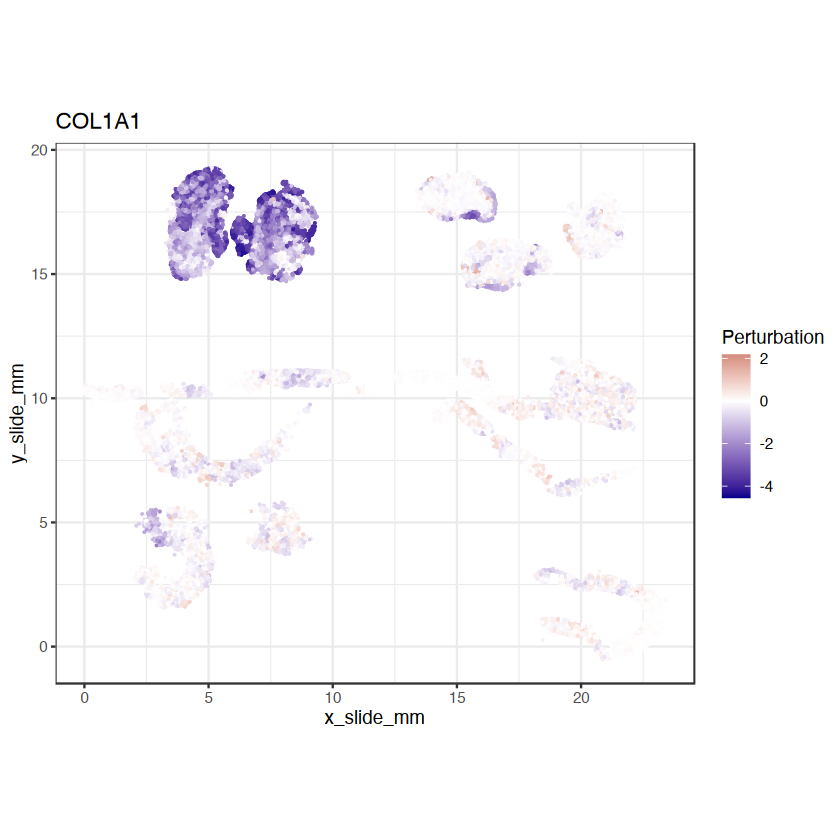

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


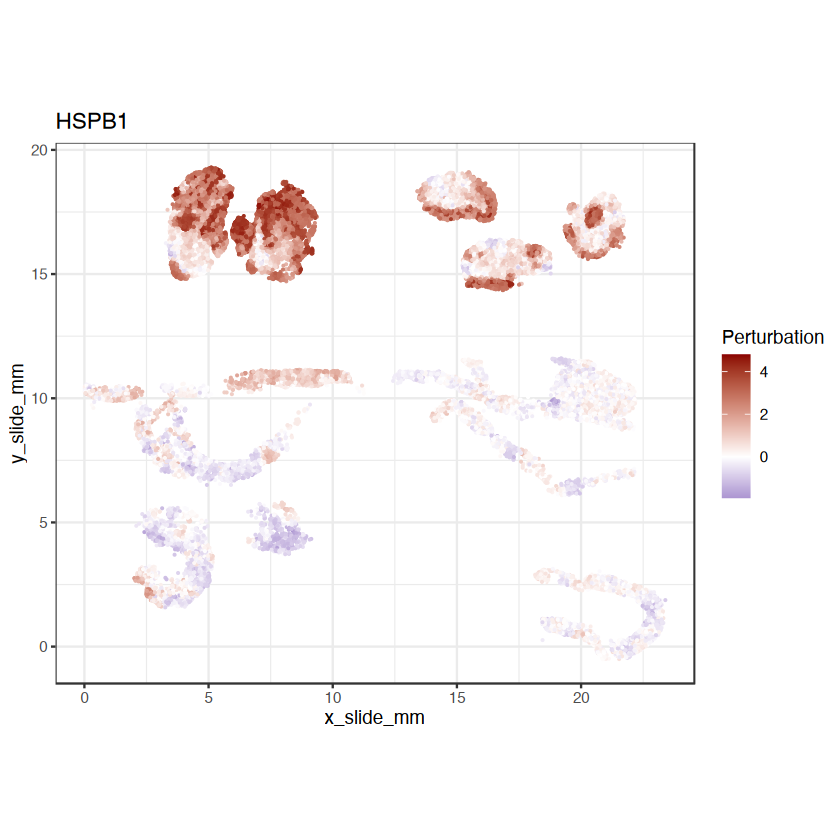

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


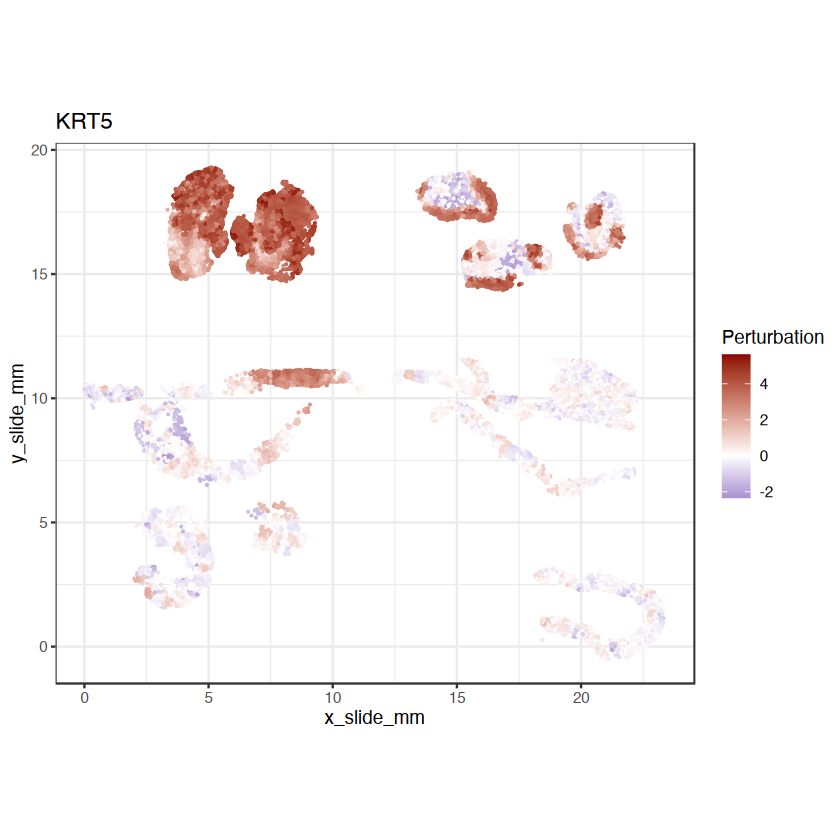

Saved 4 gene spatial plots to ../outputs/CJ_TCR_T/InSituDiff/genes 


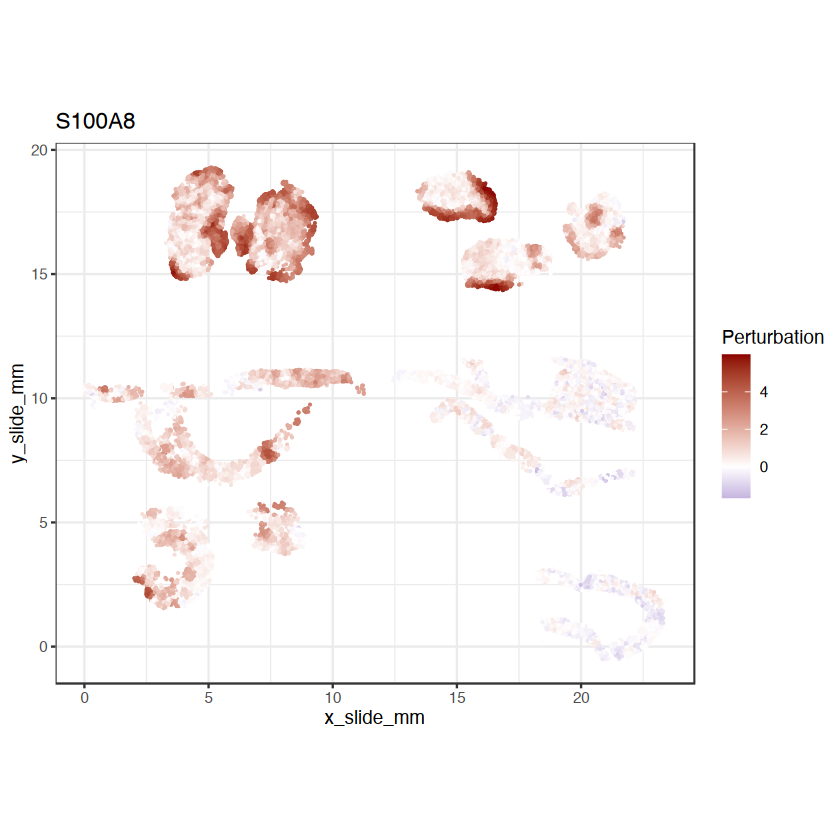

In [24]:
# Select genes to plot
if (!is.null(genes_to_plot)) {
    plot_genes <- genes_to_plot
} else {
    plot_genes <- head(
        names(sort(genescores[hpgs, "intensity"], decreasing = TRUE)),
        top_genes_to_plot
    )
}
cat("Plotting perturbation maps for:", paste(plot_genes, collapse = ", "), "\n")

# Get perturbation scores for selected genes
perturbations <- InSituDiff::getPerturbations(
    x         = norm,
    obj       = obj,
    cells     = NULL,
    genes     = plot_genes,
    residtype = residtype,
    eps       = eps_spatial
)

# Plot each gene individually
genes_dir <- file.path(out_dir, "genes")
dir.create(genes_dir, recursive = TRUE, showWarnings = FALSE)

for (gene in plot_genes) {
    plot_md <- metadata
    plot_md[[gene]] <- perturbations[rownames(plot_md), gene]

    p <- xyplot(
        cluster_column     = gene,
        metadata           = plot_md,
        x_column           = sdimx_col,
        y_column           = sdimy_col,
        ptsize             = 0.1,
        na_color           = "grey80",
        show_legend        = TRUE
    ) +
        scale_color_gradient2(low = "darkblue", mid = "white", high = "darkred",
                              midpoint = 0, name = "Perturbation") +
        labs(title = gene)

    print(p)

    ggsave(file.path(genes_dir, paste0("perturbation_spatial_", gene, ".png")),
           p, width = 10, height = 8, dpi = 150)
}
cat("Saved", length(plot_genes), "gene spatial plots to", genes_dir, "\n")

## Gene Modules (Co-perturbed Gene Clusters)

`buildGeneModules()` groups genes with spatially correlated perturbation patterns into modules. Genes within a module tend to be perturbed together in the same neighborhoods, suggesting coordinated regulation or shared biological pathways.

In [20]:
set.seed(seed)

modules <- tryCatch({
    InSituDiff::buildGeneModules(
        x              = norm,
        obj            = obj,
        genes          = "highlyperturbed",
        resolution     = resolution,
        corthresh      = corthresh,
        min_module_cor = min_module_cor,
        subsetsize     = subsetsize,
        eps            = eps_modules,
        residtype      = residtype
    )
}, error = function(e) {
    stop("buildGeneModules() failed: ", e$message)
})

print(paste("Eps used:", eps_modules))

# Print module membership
cat("Number of modules:", length(modules), "\n\n")
for (mod_name in names(modules)) {
    cat(mod_name, "(", length(modules[[mod_name]]), "genes ):",
        paste(head(modules[[mod_name]], 10), collapse = ", "),
        if (length(modules[[mod_name]]) > 10) "..." else "", "\n")
}

[1] "Eps used: 0.5"
Number of modules: 4 

KRT5_KRT19_66 ( 66 genes ): KRT5, S100A8, HSPB1, KRT13, S100A9, KRT19, B2M, SFN, TPT1, S100A2 ... 
NRXN1_TNFRSF19_51 ( 51 genes ): RPL21, APOE, TTN, NRXN1, MMP9, CCL2, SPP1, ACTG2, PRF1, IGF2 ... 
AZU1_CD8B_44 ( 44 genes ): COL1A1, PPIA, COL3A1, LTB, QRFPR, KLRK1, CD40LG, PTPRCAP, LEFTY1, AZU1 ... 
IGHG1_IGKC_14 ( 14 genes ): IGKC, IGHG1, IGHA1, IGHG2, MGP, VIM, PTGDS, S100A4, TAGLN, IGFBP7 ... 


In [21]:
# Save modules
saveRDS(modules, file.path(out_dir, "gene_modules.rds"))
cat("Saved gene_modules.rds\n")

Saved gene_modules.rds


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


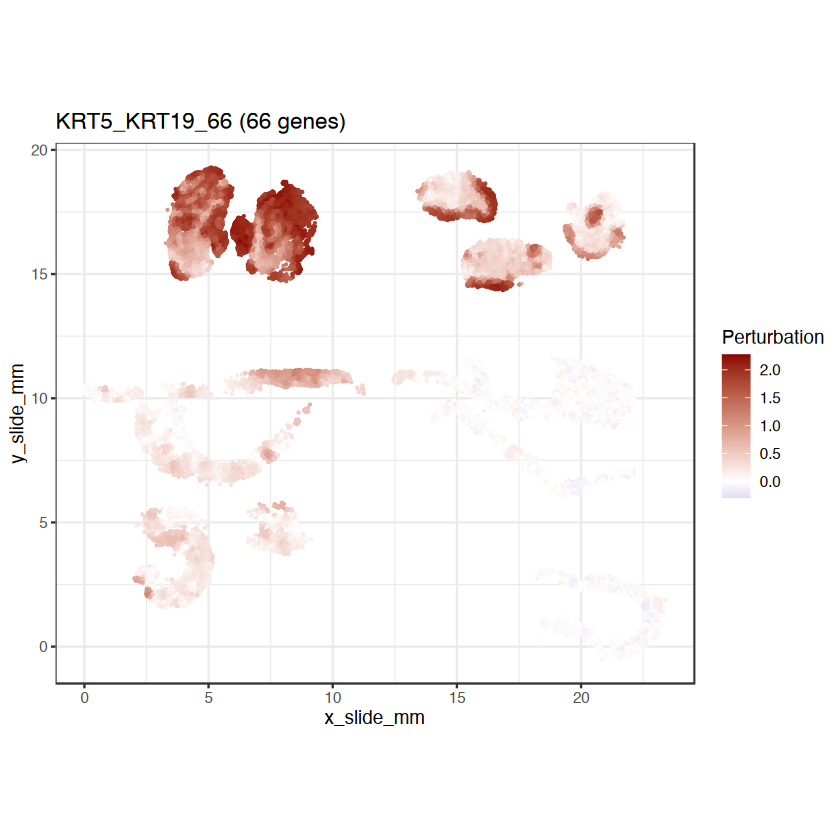

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


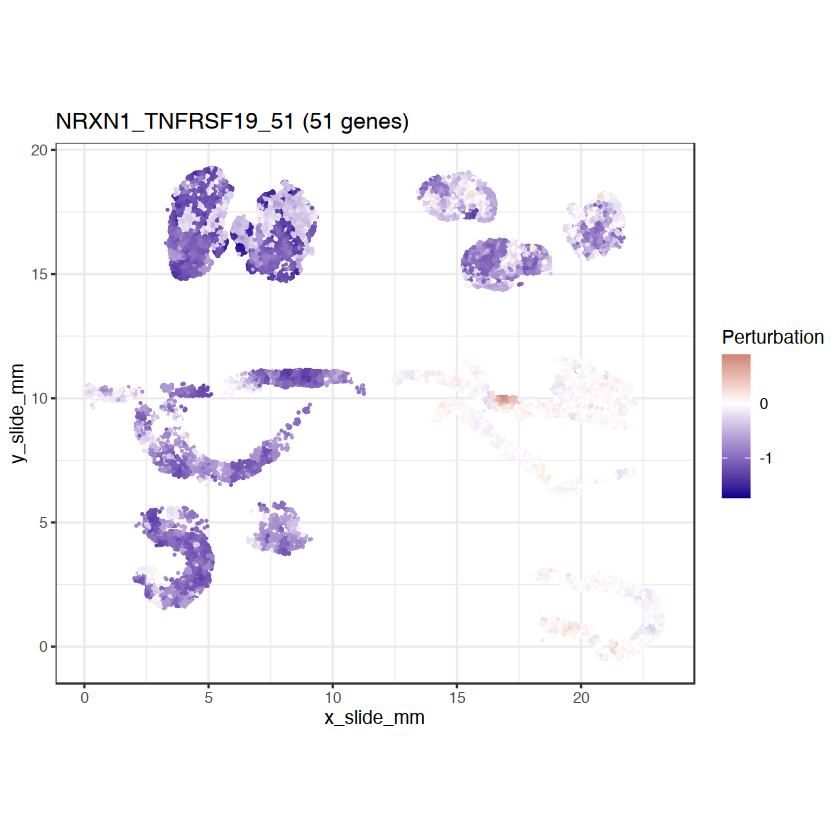

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


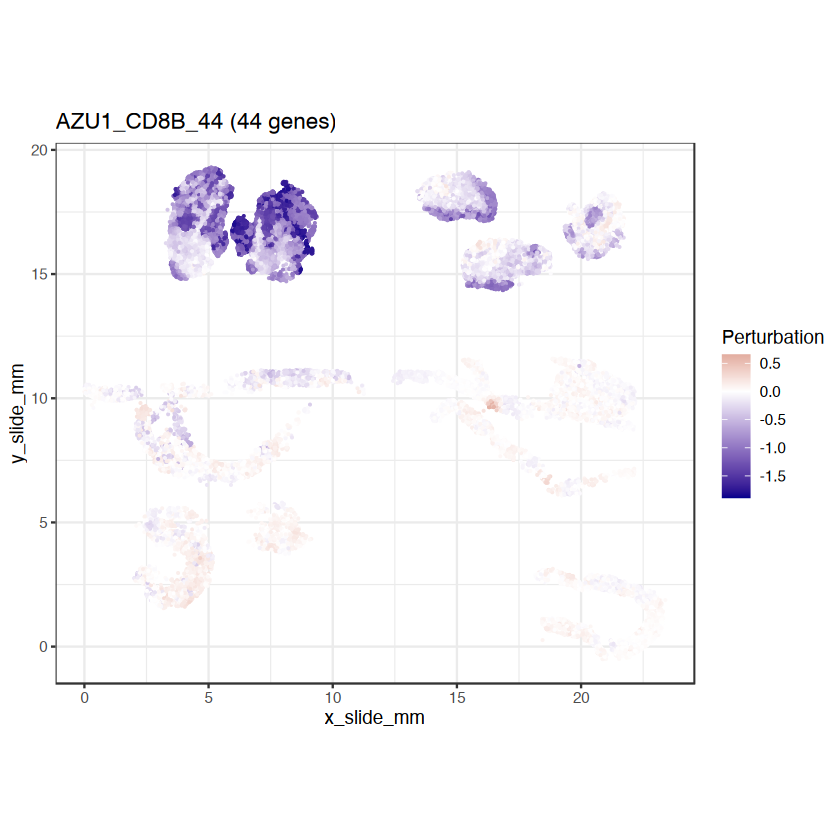

Saved 4 module spatial plots to ../outputs/CJ_TCR_T/InSituDiff/modules 


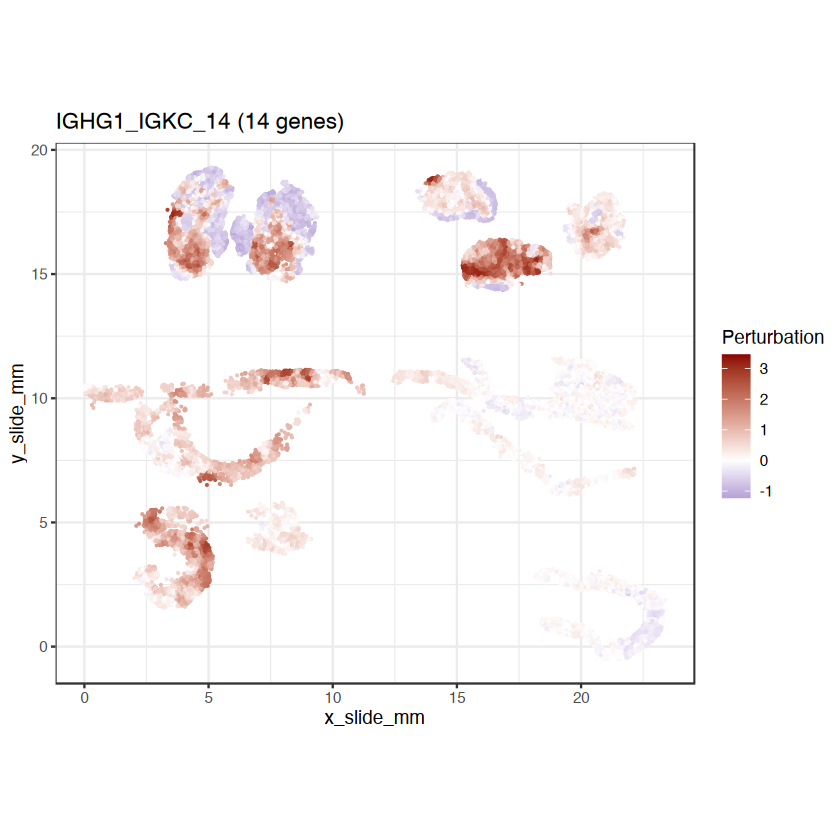

In [25]:
# Select modules to plot: all by default, or top N largest
module_sizes <- sapply(modules, length)
if (is.null(n_modules_to_plot)) {
    plot_mod_idx <- order(-module_sizes)
} else {
    plot_mod_idx <- head(order(-module_sizes), n_modules_to_plot)
}

# Get module-level perturbation scores
moduleperturbations <- InSituDiff::getPerturbations(
    x         = norm,
    obj       = obj,
    cells     = NULL,
    genes     = modules[plot_mod_idx],
    residtype = residtype,
    eps       = eps_spatial
)

# Plot and save each module individually
modules_dir <- file.path(out_dir, "modules")
dir.create(modules_dir, recursive = TRUE, showWarnings = FALSE)

for (i in seq_along(plot_mod_idx)) {
    mod_name <- colnames(moduleperturbations)[i]
    plot_md <- metadata
    plot_md[[mod_name]] <- moduleperturbations[rownames(plot_md), mod_name]

    p <- xyplot(
        cluster_column     = mod_name,
        metadata           = plot_md,
        x_column           = sdimx_col,
        y_column           = sdimy_col,
        ptsize             = 0.1,
        na_color           = "grey80",
        show_legend        = TRUE
    ) +
        scale_color_gradient2(low = "darkblue", mid = "white", high = "darkred",
                              midpoint = 0, name = "Perturbation") +
        labs(title = paste0(mod_name, " (", module_sizes[plot_mod_idx[i]], " genes)"))

    print(p)

    ggsave(file.path(modules_dir, paste0("perturbation_module_", mod_name, ".png")),
           p, width = 10, height = 8, dpi = 150)
}
cat("Saved", length(plot_mod_idx), "module spatial plots to", modules_dir, "\n")

## Spatial Domain Clustering

`clusterPerturbations()` groups cells into spatial domains based on their perturbation profiles across the highly perturbed genes. This reveals regions of tissue with distinct perturbation patterns.

Returns:
- `res$clust`: Per-cell cluster assignment
- `res$means`: Mean perturbation per gene (rows) per cluster (columns)

In [26]:
set.seed(seed)

res <- tryCatch({
    InSituDiff::clusterPerturbations(
        x         = norm,
        obj       = obj,
        cells     = NULL,
        genes     = "highlyperturbed", # hpgs,
        residtype = residtype,
        nclust    = nclust
    )
}, error = function(e) {
    stop("clusterPerturbations() failed: ", e$message)
})

cat("Cluster sizes:\n")
print(table(res$clust))
cat("\nMean perturbation matrix dimensions:", dim(res$means), "\n")

Cluster sizes:

domain1 domain2 domain3 domain4 domain5 domain6 
   6668   17762    6178    2024   14581    2787 

Mean perturbation matrix dimensions: 191 6 


Saved spatial_domain_map.png


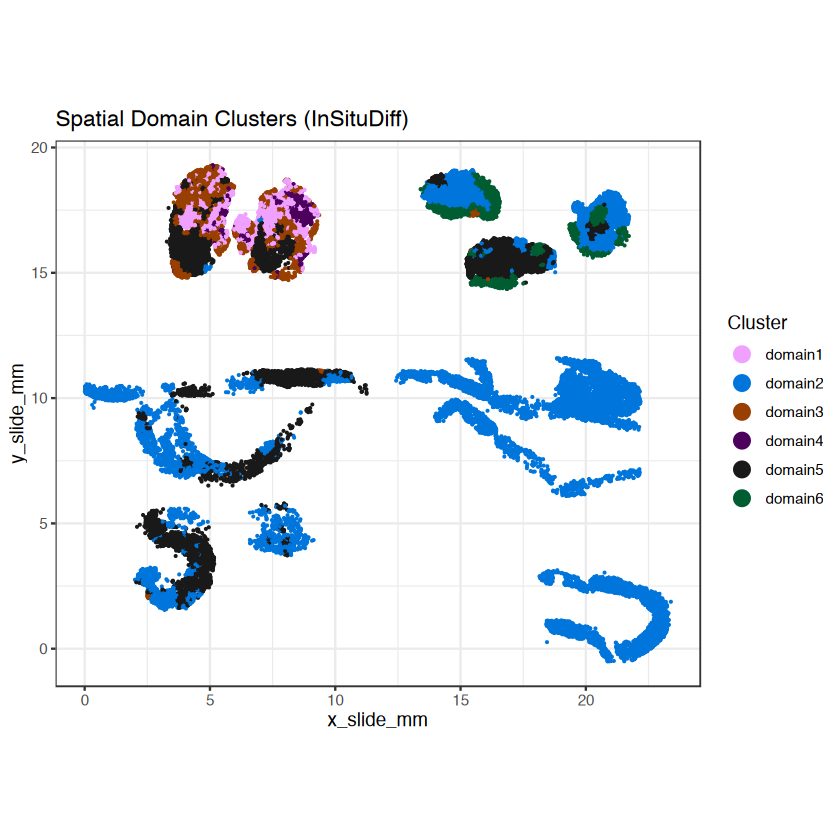

In [33]:
# Spatial scatter plot colored by cluster assignment
plot_md <- metadata
plot_md$perturbation_cluster <- as.factor(res$clust)

p_clusters <- xyplot(
    cluster_column = "perturbation_cluster",
    metadata       = plot_md,
    x_column       = sdimx_col,
    y_column       = sdimy_col,
    ptsize         = 0.1,
    na_color       = "grey80",
    show_legend    = TRUE
) + labs(title = "Spatial Domain Clusters (InSituDiff)", color = "Cluster")

p_clusters

ggsave(file.path(out_dir, "spatial_domain_map.png"),
       p_clusters, width = 10, height = 8, dpi = 150)
cat("Saved spatial_domain_map.png\n")

quartz_off_screen 
                3

Saved perturbation_heatmap.png


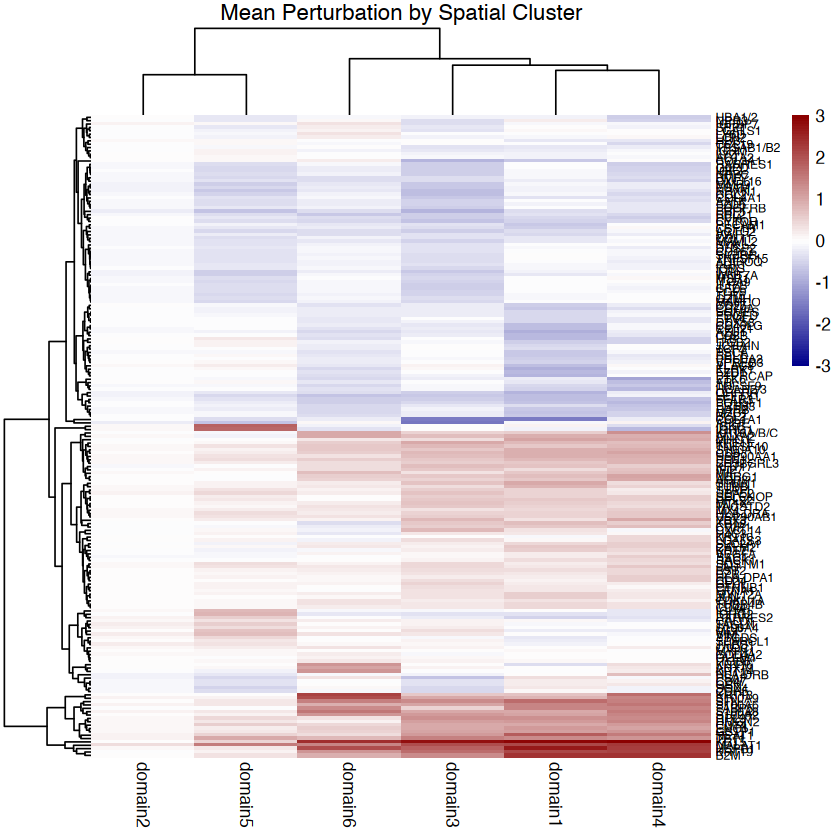

In [34]:
# Heatmap of mean perturbation per gene (rows) per cluster (columns)
heatmap_colors <- colorRampPalette(c("darkblue", "white", "darkred"))(100)
heatmap_breaks <- seq(-3, 3, length.out = 101)

# Save to file (pheatmap uses grid graphics)
png(file.path(out_dir, "perturbation_heatmap.png"), width = 10, height = 8, units = "in", res = 150)
pheatmap(
    res$means,
    breaks          = heatmap_breaks,
    color           = heatmap_colors,
    cluster_rows    = TRUE,
    cluster_cols    = TRUE,
    main            = "Mean Perturbation by Spatial Cluster",
    fontsize_row    = 7,
    fontsize_col    = 10
)
dev.off()

# Display inline
pheatmap(
    res$means,
    breaks          = heatmap_breaks,
    color           = heatmap_colors,
    cluster_rows    = TRUE,
    cluster_cols    = TRUE,
    main            = "Mean Perturbation by Spatial Cluster",
    fontsize_row    = 7,
    fontsize_col    = 10
)

cat("Saved perturbation_heatmap.png\n")

In [41]:
# Save cluster assignments
cluster_df <- data.frame(
    cell_id = rownames(metadata),
    cluster = res$clust,
    row.names = NULL
)
write.csv(cluster_df, file.path(out_dir, "spatial_domain_clusters.csv"), row.names = FALSE)
cat("Saved spatial_domain_clusters.csv\n")

Saved spatial_domain_clusters.csv


## Session Info & Reproducibility

In [42]:
# Print configuration summary
config_params <- list(
    study_name          = study_name,
    seurat_rds_path     = seurat_rds_path,
    ASSAY_NAME          = ASSAY_NAME,
    sdimx_col           = sdimx_col,
    sdimy_col           = sdimy_col,
    tissue_col          = tissue_col,
    control_pattern     = control_pattern,
    k                   = k,
    eps_summarize       = eps_summarize,
    eps_spatial         = eps_spatial,
    eps_modules         = eps_modules,
    eps_perturb         = eps_perturb,
    residtype           = residtype,
    n_top_genes         = n_top_genes,
    nclust              = nclust,
    subsetsize          = subsetsize,
    seed                = seed,
    subset              = subset,
    subset_n            = subset_n,
    resolution          = resolution,
    corthresh           = corthresh,
    min_module_cor      = min_module_cor,
    top_genes_to_plot   = top_genes_to_plot,
    n_modules_to_plot   = ifelse(is.null(n_modules_to_plot), "all", n_modules_to_plot),
    n_hpgs_found        = length(hpgs),
    n_modules_found     = length(modules),
    output_dir          = out_dir
)

cat("=== Run Configuration ===\n")
for (nm in names(config_params)) {
    cat(sprintf("  %-22s: %s\n", nm, as.character(config_params[[nm]])))
}

sessionInfo()

=== Run Configuration ===
  study_name            : CJ_TCR_T
  seurat_rds_path       : /Users/fs2829/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/HIMC_CosMX/Project_CJ/outputs/CJ_TCR_T/seurat_objects/annotated_object_CJ_TCR_T_louvain_final_hieratype_predictors.RDS
  ASSAY_NAME            : RNA
  sdimx_col             : x_slide_mm
  sdimy_col             : y_slide_mm
  tissue_col            : region_detail
  control_pattern       : Stable
  k                     : 50
  eps_summarize         : 0.1
  eps_spatial           : 0.2
  eps_modules           : 0.5
  eps_perturb           : 1
  residtype             : log2ratio
  n_top_genes           : 20
  nclust                : 6
  subsetsize            : 1e+05
  seed                  : 123
  subset                : TRUE
  subset_n              : 50000
  resolution            : 0.02
  corthresh             : 0.3
  min_module_cor        : 0.25
  top_genes_to_plot     : 4
  n_modules_to_plot     : all
  n_hpgs_found      

R version 4.5.2 (2025-10-31)
Platform: x86_64-apple-darwin13.4.0
Running under: macOS Tahoe 26.2

Matrix products: default
BLAS/LAPACK: /Users/fs2829/miniforge3/envs/COSMX_RNA_env_proj_CJ/lib/libopenblasp-r0.3.30.dylib;  LAPACK version 3.12.0

locale:
[1] C/C.UTF-8/C/C/C/C

time zone: America/New_York
tzcode source: system (macOS)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] viridis_0.6.5         viridisLite_0.4.3     ggrepel_0.9.7        
 [4] data.table_1.18.2.1   dplyr_1.2.0           pheatmap_1.0.13      
 [7] patchwork_1.3.2       ggplot2_4.0.2         Matrix_1.7-4         
[10] InSituDiff_0.0.0.9000 Seurat_5.4.0          SeuratObject_5.3.0   
[13] sp_2.2-1             

loaded via a namespace (and not attached):
  [1] RColorBrewer_1.1-3     jsonlite_2.0.0         magrittr_2.0.4        
  [4] spatstat.utils_3.2-1   farver_2.1.2           ragg_1.5.0            
  [7] vctrs_0.7.1            ROCR_1.0

In [43]:
# Save run summary to text file
summary_file <- file.path(out_dir, "run_summary.txt")
sink(summary_file)
cat("InSituDiff Analysis Run Summary\n")
cat("Date:", format(Sys.time(), "%Y-%m-%d %H:%M:%S"), "\n\n")
cat("=== Configuration ===\n")
for (nm in names(config_params)) {
    cat(sprintf("  %-22s: %s\n", nm, as.character(config_params[[nm]])))
}
cat("\n=== Highly Perturbed Genes ===\n")
cat(paste(hpgs, collapse = ", "), "\n")
cat("\n=== Session Info ===\n")
sessionInfo()
sink()
cat("Saved run_summary.txt to", out_dir, "\n")

# List all output files
cat("\n=== Output Files ===\n")
print(list.files(out_dir, full.names = FALSE))

R version 4.5.2 (2025-10-31)
Platform: x86_64-apple-darwin13.4.0
Running under: macOS Tahoe 26.2

Matrix products: default
BLAS/LAPACK: /Users/fs2829/miniforge3/envs/COSMX_RNA_env_proj_CJ/lib/libopenblasp-r0.3.30.dylib;  LAPACK version 3.12.0

locale:
[1] C/C.UTF-8/C/C/C/C

time zone: America/New_York
tzcode source: system (macOS)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] viridis_0.6.5         viridisLite_0.4.3     ggrepel_0.9.7        
 [4] data.table_1.18.2.1   dplyr_1.2.0           pheatmap_1.0.13      
 [7] patchwork_1.3.2       ggplot2_4.0.2         Matrix_1.7-4         
[10] InSituDiff_0.0.0.9000 Seurat_5.4.0          SeuratObject_5.3.0   
[13] sp_2.2-1             

loaded via a namespace (and not attached):
  [1] RColorBrewer_1.1-3     jsonlite_2.0.0         magrittr_2.0.4        
  [4] spatstat.utils_3.2-1   farver_2.1.2           ragg_1.5.0            
  [7] vctrs_0.7.1            ROCR_1.0

Saved run_summary.txt to ../outputs/CJ_TCR_T/InSituDiff 

=== Output Files ===
[1] "gene_modules.rds"             "gene_perturbation_scores.csv"
[3] "genes"                        "modules"                     
[5] "run_summary.txt"              "spatial_domain_clusters.csv" 
[7] "spatial_domain_map.png"      
